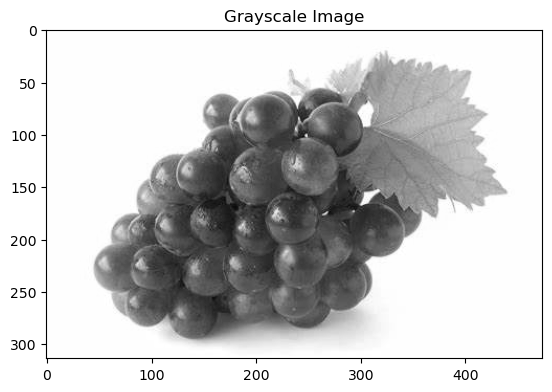

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread("grapes.jpg")  # Update path if needed
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
if image is None:
    raise FileNotFoundError("Image not found. Check the file path.")
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.show()

# GRABCUT

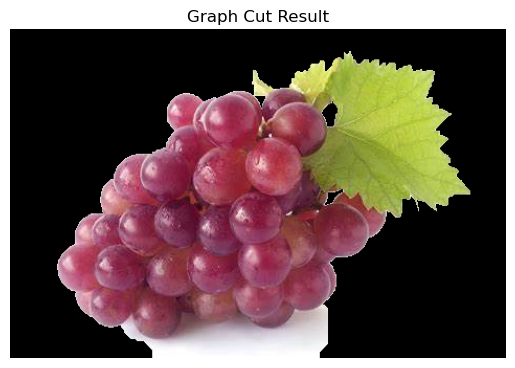

In [38]:
  

# Initialize the mask, background, and foreground models
mask = np.zeros(image.shape[:2], np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# Define the rectangle for GrabCut (ensuring it stays within image bounds)
h, w = image.shape[:2]
rect = (max(0, min(40, w-1)), max(0, min(10, h-1)), min(400, w-40), min(350, h-10))

# Apply GrabCut algorithm
cv2.grabCut(image, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

# Create a mask where 0 and 2 (background) are set to 0, and 1 and 3 (foreground) are set to 1
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

# Apply the mask to the image
graph_cut_result = image * mask2[:, :, np.newaxis]

# Convert BGR (OpenCV default) to RGB for displaying with matplotlib
graph_cut_result_rgb = cv2.cvtColor(graph_cut_result, cv2.COLOR_BGR2RGB)

# Display the result
plt.imshow(graph_cut_result_rgb)
plt.title("Graph Cut Result")
plt.axis('off')  # Hide axes for better visualization
plt.show()

#  Mean Shift Segmentation with Edge Highlight


In [ ]:
mean_shift = cv2.pyrMeanShiftFiltering(image, 50, 50)
plt.imshow(cv2.cvtColor(mean_shift, cv2.COLOR_BGR2RGB))
plt.title("Mean Shift Segmentation")
plt.show()

# 3. K-Means Clustering


In [41]:
 Z = image.reshape((-1, 3))
Z = np.float32(Z)
k = 5
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv2.kmeans(Z, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
kmeans_result = centers[labels.flatten()].reshape(image.shape)
kmeans_result = np.uint8(kmeans_result)

# 4. Otsu's Thresholding


In [42]:
 thresh_val, otsu_thresh = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# REGION GROWING

In [43]:
# 5. Region Growing (Fixed Version)
def region_growing(image, seed, threshold=5):
    height, width = image.shape
    segmented = np.zeros_like(image, np.uint8)
    seed_value = image[seed[1], seed[0]]
    stack = [seed]
    visited = set()

    while stack:
        x, y = stack.pop()
        if (x, y) in visited:
            continue
        visited.add((x, y))
        if abs(int(image[y, x]) - int(seed_value)) < threshold:
            segmented[y, x] = 255
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < width and 0 <= ny < height:
                    stack.append((nx, ny))
    return segmented

seed_point = (200,100)
region_growing_result = region_growing(gray_image, seed_point, threshold=63)

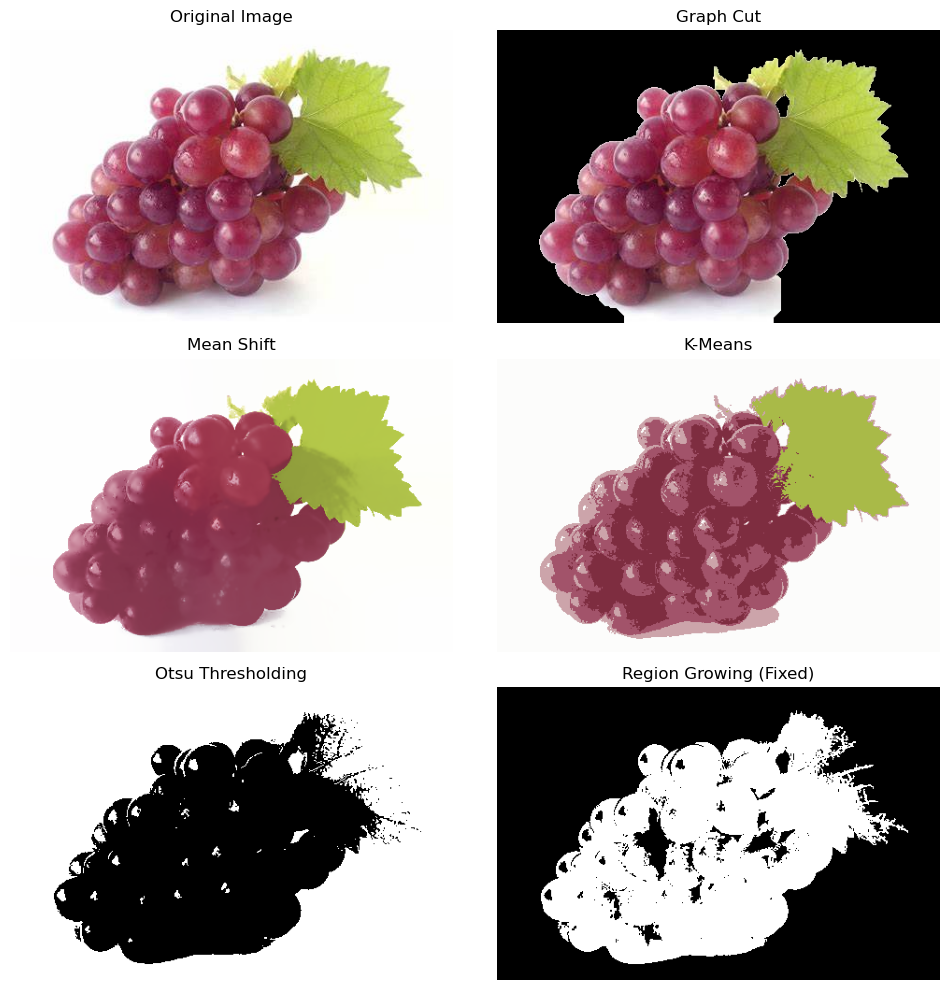

In [44]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original Image")
axes[0, 1].imshow(cv2.cvtColor(graph_cut_result, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("Graph Cut")
axes[1, 0].imshow(cv2.cvtColor(mean_shift, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Mean Shift")
axes[1, 1].imshow(cv2.cvtColor(kmeans_result, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("K-Means")
axes[2, 0].imshow(otsu_thresh, cmap='gray')
axes[2, 0].set_title("Otsu Thresholding")
axes[2, 1].imshow(region_growing_result, cmap='gray')
axes[2, 1].set_title("Region Growing (Fixed)")

for ax in axes.flatten():
    ax.axis("off")
plt.tight_layout()
plt.show()